# Trader Behaviour vs Bitcoin Market Sentiment
**Assignment for Data Science Internship – Primetrade.ai**

In this notebook I am trying to see if there is any link between how the crypto
market "feels" (Fear / Greed) on a given day and how traders on Hyperliquid
actually perform on that day.

Two files are used:
- `fear_greed_index.csv` -> daily sentiment label (Fear, Greed, etc.)
- `historical_data.csv` -> individual trade level data (~2.1 lakh rows, 32 accounts)

I have kept the analysis simple and tried to ask 4-5 clear questions so that the insights are easy to read.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print('libraries loaded')

libraries loaded


## Step 1: Load the data

Reading both csv files and checking their shape 

In [3]:
fg = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print('Fear-Greed data shape:', fg.shape)
print('Trades data shape:', trades.shape)

print(fg.head())

Fear-Greed data shape: (2644, 4)
Trades data shape: (211224, 16)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [4]:
print(trades[['Account','Coin','Side','Direction','Closed PnL','Size USD','Timestamp IST']].head())

                                      Account  Coin Side Direction  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY       Buy   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY       Buy   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY       Buy   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY       Buy   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  BUY       Buy   

   Closed PnL  Size USD     Timestamp IST  
0         0.0   7872.16  02-12-2024 22:50  
1         0.0    127.68  02-12-2024 22:50  
2         0.0   1150.63  02-12-2024 22:50  
3         0.0   1142.04  02-12-2024 22:50  
4         0.0     69.75  02-12-2024 22:50  


Note: the assignment mentions a `leverage` column but the actual
`historical_data.csv` file does not have one. So leverage is not used anywhere in this analysis, everything is
based on the columns that are actually present.

In [6]:
print(list(trades.columns))

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


## Step 2: Clean up dates and merge the two datasets
The `Timestamp IST` in the trades file contains both date and time, so I only need the date part to match it with the sentiment file. I do a left merge (keeping every trade, even if by chance a date does not have a sentiment value) after converting both into plain `date` objects.

In [ ]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

data = pd.merge(trades, fg[['date', 'classification', 'value']], on='date', how='left')

missing = data['classification'].isna().sum()
print(f'{missing} trades out of {len(data)} could not be matched to a sentiment value so dropping these')
data = data.dropna(subset=['classification'])

data['is_win'] = data['Closed PnL'] > 0

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
data['classification'] = pd.Categorical(data['classification'], categories=sentiment_order, ordered=True)

print(data['classification'].value_counts().sort_index())

6 trades out of 211224 could not be matched to a sentiment value (dropping these)
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


## Step 3: Checking if trader performance change with sentiment

Grouping all trades by the sentiment of that day with:
- number of trades
- average PnL per trade
- win rate (% of trades that closed with profit)
- average trade size in USD

In [10]:
summary = data.groupby('classification').agg(
    trades=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('is_win', 'mean'),
    avg_trade_size_usd=('Size USD', 'mean')
)
summary['win_rate'] = (summary['win_rate'] * 100).round(2)
summary['avg_pnl'] = summary['avg_pnl'].round(2)
print(summary)

                trades  avg_pnl     total_pnl  win_rate  avg_trade_size_usd
classification                                                             
Extreme Fear     21400    34.54  7.391102e+05     37.06         5349.731843
Fear             61837    54.29  3.357155e+06     42.08         7816.109931
Neutral          37686    34.31  1.292921e+06     39.70         4782.732661
Greed            50303    42.74  2.150129e+06     38.48         5736.884375
Extreme Greed    39992    67.89  2.715171e+06     46.49         3112.251565


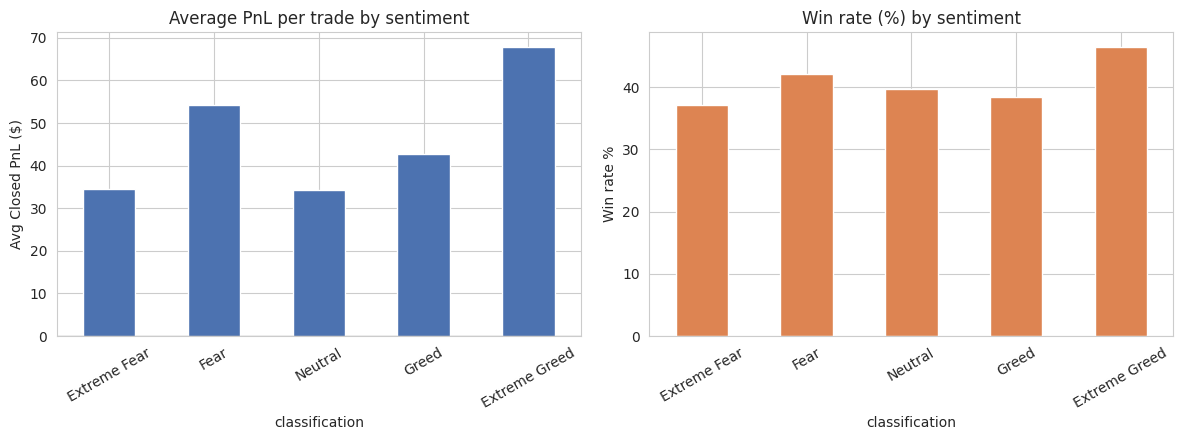

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

summary['avg_pnl'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Average PnL per trade by sentiment')
axes[0].set_ylabel('Avg Closed PnL ($)')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)

summary['win_rate'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Win rate (%) by sentiment')
axes[1].set_ylabel('Win rate %')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Inference:** highest win rate and average PnL are on both "Extreme Greed" days and lowest on "Extreme Fear" days. So, on a per-trade basis, traders are actually doing better when the market is greedy, not when it’s fearful.

## Step 4: Are traders herding, or going contrarian?

Here I check the % of BUY orders on each type of sentiment day. If traders
are herding, we'd expect more buying on Greed days and more selling on Fear
days.

classification
Extreme Fear     51.10
Fear             48.95
Neutral          50.33
Greed            48.86
Extreme Greed    44.86
Name: Side, dtype: float64


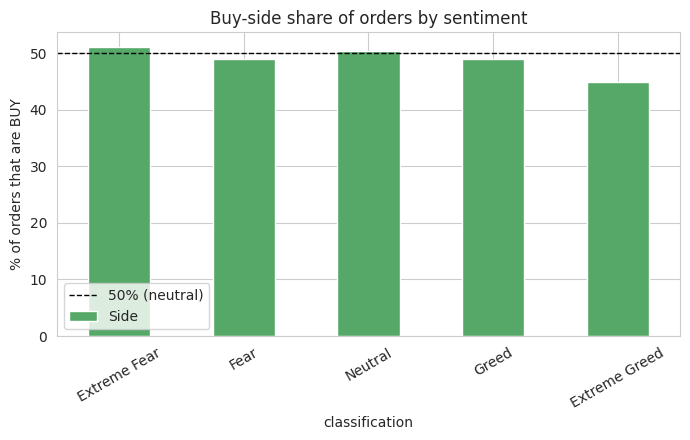

In [14]:
buy_pct = data.groupby('classification')['Side'].apply(lambda s: (s == 'BUY').mean() * 100).round(2)
print(buy_pct)

plt.figure(figsize=(7, 4.5))
buy_pct.plot(kind='bar', color='#55A868')
plt.axhline(50, color='black', linestyle='--', linewidth=1, label='50% (neutral)')
plt.ylabel('% of orders that are BUY')
plt.title('Buy-side share of orders by sentiment')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Inference:** buying share is actually a bit higher during Extreme Fear (~51%) and lower during Extreme Greed (~45%).  So traders in this dataset are, on average, mildly contrarian in terms of order flow.They buy relatively more when the market is fearful. But Step 3 showed they still make less money doing that, meaning the timing of the contrarian bet is not great.

## Step 5: Do the best traders behave differently from the rest?

Dividing the 32 accounts into a top 20% and bottom 20% group based on their total
Comparison by sentiment of closed PnL and win rate in each group. The concept is to see if top traders react differently to sentiment than an average trader.

In [17]:
account_pnl = data.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
n_top = max(1, int(len(account_pnl) * 0.2))

top_accounts = account_pnl.head(n_top).index
bottom_accounts = account_pnl.tail(n_top).index

print('Total accounts:', len(account_pnl))
print('Accounts in top 20% group:', len(top_accounts))

top_group = data[data['Account'].isin(top_accounts)]
bottom_group = data[data['Account'].isin(bottom_accounts)]

top_wr = top_group.groupby('classification')['is_win'].mean() * 100
bottom_wr = bottom_group.groupby('classification')['is_win'].mean() * 100

compare = pd.DataFrame({'Top 20% traders': top_wr, 'Bottom 20% traders': bottom_wr}).round(2)
print(compare)

Total accounts: 32
Accounts in top 20% group: 6
                Top 20% traders  Bottom 20% traders
classification                                     
Extreme Fear              38.16               34.00
Fear                      42.03               36.03
Neutral                   42.59               22.78
Greed                     38.55               48.41
Extreme Greed             51.23               36.69


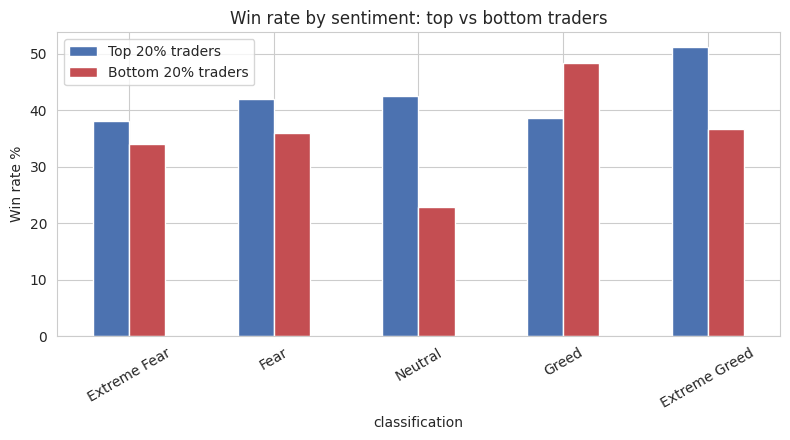

In [18]:
compare.plot(kind='bar', figsize=(8, 4.5), color=['#4C72B0', '#C44E52'])
plt.ylabel('Win rate %')
plt.title('Win rate by sentiment: top vs bottom traders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Inference:** the top 20% traders have a significantly higher win rate than the bottom 20% in almost every sentiment bucket, and the gap is largest on “Extreme Greed” days. So being a good trader is not just about picking the right sentiment day but it’s a consistent edge, but that edge is amplified particularly when the market is euphoric (perhaps because good traders manage risk better when everyone else is over-leveraged).

## Step 6: Does the coin traders prefer change with sentiment?

Check on the top 5 most-traded coins during Extreme Fear vs
Extreme Greed days, side by side.

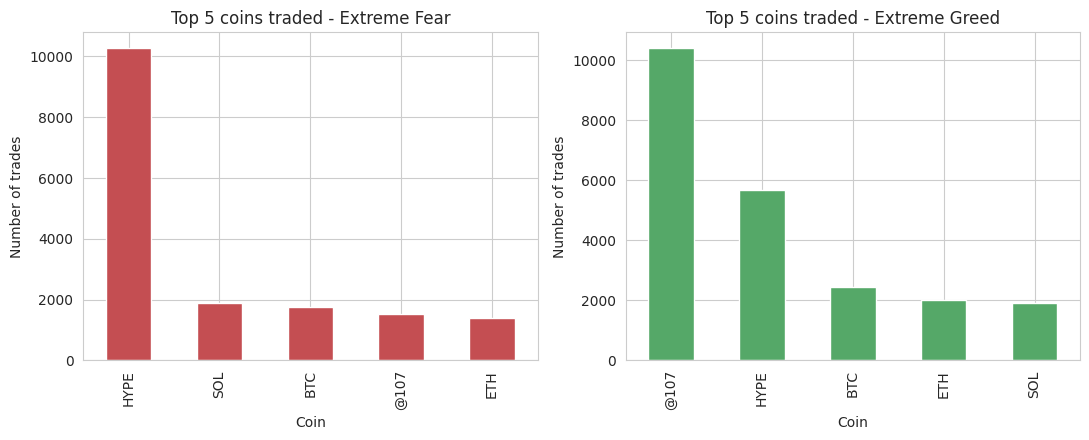

In [21]:
fear_coins = data[data['classification'] == 'Extreme Fear']['Coin'].value_counts().head(5)
greed_coins = data[data['classification'] == 'Extreme Greed']['Coin'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fear_coins.plot(kind='bar', ax=axes[0], color='#C44E52')
axes[0].set_title('Top 5 coins traded - Extreme Fear')
axes[0].set_ylabel('Number of trades')

greed_coins.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Top 5 coins traded - Extreme Greed')
axes[1].set_ylabel('Number of trades')

plt.tight_layout()
plt.show()

**Inference:** HYPE dominates trading activity during Extreme
Fear days while a token labelled `@107` dominates during Extreme Greed days. BTC, ETH and SOL stay
in the top-5 on both sides, which makes sense since they are the more liquid,
"safer" coins people fall back on regardless of mood.

## Step 7: Correlation

Correlating the daily sentiment score (0-100,
where 0 = extreme fear and 100 = extreme greed) with the total PnL made by
all traders that day.

Correlation between sentiment score and daily total PnL: -0.083


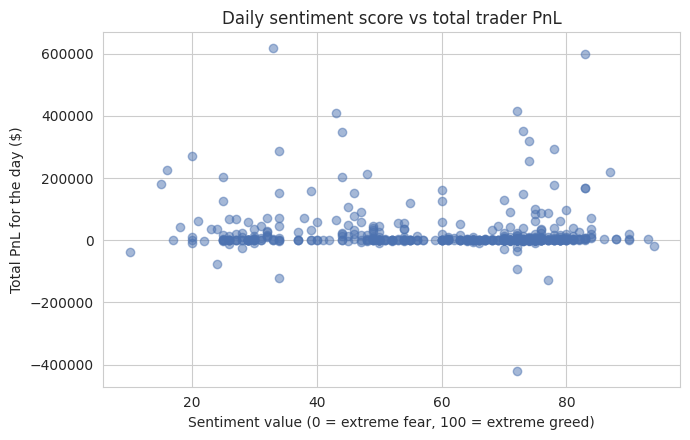

In [24]:
daily = data.groupby('date').agg(
    total_pnl=('Closed PnL', 'sum'),
    sentiment_value=('value', 'mean')
).dropna()

corr = daily['sentiment_value'].corr(daily['total_pnl'])
print('Correlation between sentiment score and daily total PnL:', round(corr, 3))

plt.figure(figsize=(7, 4.5))
plt.scatter(daily['sentiment_value'], daily['total_pnl'], alpha=0.5, color='#4C72B0')
plt.xlabel('Sentiment value (0 = extreme fear, 100 = extreme greed)')
plt.ylabel('Total PnL for the day ($)')
plt.title('Daily sentiment score vs total trader PnL')
plt.tight_layout()
plt.show()

**Inference:** the correlation is very weak (close to 0), so the
raw sentiment "score" on its own is not a great predictor of a good or bad
trading day. It's the "category" (Extreme Fear vs Extreme Greed
specifically) which matters more than a smooth linear score, which
also matches what the bar charts in Step 3 showed.

## Key Insights

- Traders do best (highest win rate & avg PnL) on **Extreme Greed** days and
  worst on **Extreme Fear** days 
- Order flow is only slightly contrarian as traders buy a bit more during
  fear and sell a bit more during greed, but this mild contrarian tilt does
  not translate into better PnL during fear.
- The top 20% traders by PnL keep a consistently better win rate than the
  bottom 20% across every sentiment regime, and the gap is biggest during
  Extreme Greed, suggesting good traders capitalise more on euphoric markets
  rather than avoiding them.
- Coin preference shifts with sentiment (HYPE-heavy during fear, `@107`-heavy
  during greed) while BTC/ETH/SOL remain popular in both.
- A simple linear correlation between the sentiment score and daily PnL is
  weak, so sentiment score alone should not be used as a standalone trading
  signal — it's more useful when combined with account-level behaviour
  (e.g., which trader, what coin) than as a blanket market signal.

**Possible next step:** a small
classification model that predicts whether a trade will be profitable using
sentiment + coin + side + trade size as features, to see if these variables
actually carry predictive power beyond simple grouping.